In [1]:
!pip install torch


In [2]:
!pip install shap


Cleaned Data Shape:  (145123, 26)
X Shape:  (145123, 25)
y Shape:  (145123,)
Full preprocessed data: X=(145123, 25), y=(145123,)

----- Training -----

========== Federated Round START ==========
[Sensor 1] Training data filtered: 46473 normal samples. Discarded 4320 malicious/anomaly packets to ensure robust clean training.
[Sensor 1] Input dimension: 25
[Sensor 1] Training from scratch.
[Sensor 1] Started training!

[DEBUG] Input tensor stats: min=-2.4025, max=2.3627, mean=-0.0708
[DEBUG] Input tensor shape: torch.Size([46464, 10, 25])
[Sensor 1] Epoch 1/5 | Loss: 0.7245
[Sensor 1] Epoch 2/5 | Loss: 0.6825
[Sensor 1] Epoch 3/5 | Loss: 0.6621
[Sensor 1] Epoch 4/5 | Loss: 0.6505
[Sensor 1] Epoch 5/5 | Loss: 0.6425
[Sensor 1] Final Local Loss: 0.6425

[Sensor 1] Sending data to Bridge 1

[Bridge 1] Received data from Sensor 1

[Sensor 2] Training data filtered: 46546 normal samples. Discarded 4247 malicious/anomaly packets to ensure robust clean training.
[Sensor 2] Input dimension: 25


  0%|          | 0/10 [00:00<?, ?it/s]

SHAP analysis completed. Plot saved to 'SHAP_Feature_Importance.png'.


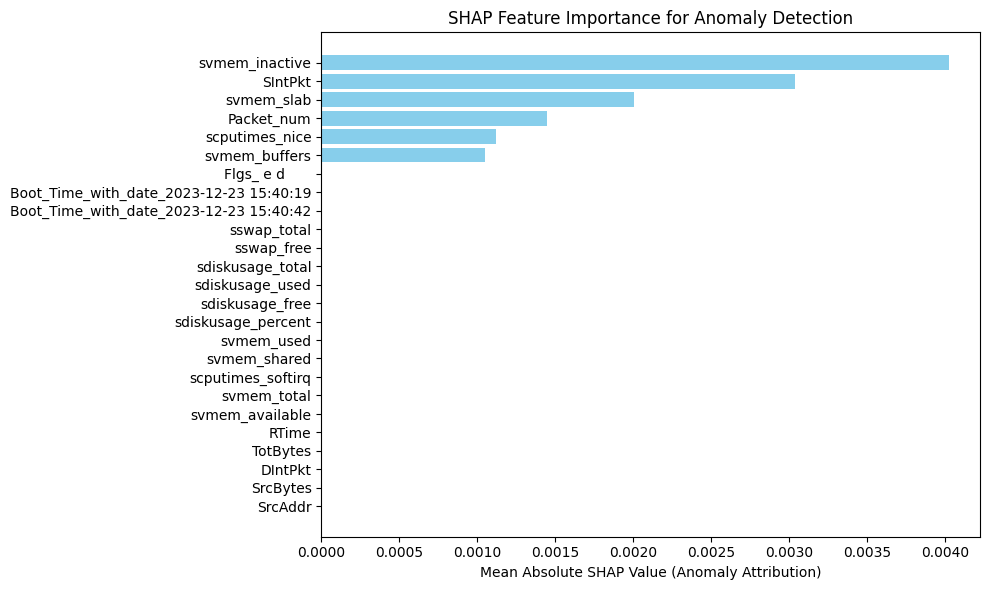

In [3]:
# -*- coding: utf-8 -*-
"""FL_based_IOT.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1TvZVU2NYQU9UFFnFiduywOnMs_U1wmNq
"""

# !pip install torch

# !pip install shap

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import math
import time
import os
import matplotlib.pyplot as plt
from collections import deque
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.impute import SimpleImputer
from torch.utils.data import TensorDataset, DataLoader
import copy
import joblib
import gc
import shap
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Data Preprocessing Class
class preprocess_data():
    def __init__(self, df):
        self.le = {}
        self.ss = {}
        self.feature_selecter = {}
        self.df = df
        self.num_cols = []
        self.cat_cols = []
        self.features = []
        self.target = ""
        self.clean_df = []
        self.X = []
        self.y = []
        self.X_train = []
        self.X_test = []
        self.y_train = []
        self.y_test = []

    def handling_missing_values(self):

        # Set features and target (explicitly exclude Label and Attack_categories to prevent leakage)
        self.target = 'Label' if 'Label' in self.df.columns else self.df.columns[-1]
        self.features = [col for col in self.df.columns if col not in [self.target, 'Attack_categories']]

        # Identify types
        self.num_cols = self.df[self.features].select_dtypes(include=np.number).columns.tolist()
        self.cat_cols = self.df[self.features].select_dtypes(include=['object']).columns.tolist()

        # Handle infinite values
        for col in self.df.columns:
            if pd.api.types.is_numeric_dtype(self.df[col]):
                mean_val = self.df[col][np.isfinite(self.df[col])].mean()
                self.df[col] = self.df[col].replace([np.inf, -np.inf], mean_val)

        # Impute numerical
        for col in self.num_cols:
            if col == self.target:
                continue
            if self.df[col].isnull().sum() > 0:
                imputer = SimpleImputer(strategy='mean')
                self.df[col] = imputer.fit_transform(self.df[[col]])

        # Impute categorical
        for col in self.cat_cols:
            if col == self.target:
                continue
            if self.df[col].isnull().sum() > 0:
                imputer = SimpleImputer(strategy='most_frequent')
                self.df[col] = imputer.fit_transform(self.df[[col]])


    def scaling_encoding(self):
        # Recalculate categorical and numeric cols from training features
        self.num_cols = self.df[self.features].select_dtypes(include=np.number).columns.tolist()
        self.cat_cols = self.df[self.features].select_dtypes(include=['object']).columns.tolist()

        high_cardinality_cols = []
        low_cardinality_cols = []

        for col in self.cat_cols:
            unique_vals = self.df[col].nunique()
            if unique_vals > 10:
                high_cardinality_cols.append(col)
            else:
                low_cardinality_cols.append(col)

        # --- Label encode high-cardinality ---
        for col in high_cardinality_cols:
            le = LabelEncoder()
            self.df[col] = le.fit_transform(self.df[col].astype(str))
            self.le[col] = le

        # --- One-hot encode low-cardinality ---
        self.df = pd.get_dummies(self.df, columns=low_cardinality_cols, drop_first=True)

        # --- Update numerical columns after encoding (excluding target and leakage sources) ---
        encoded_features = [c for c in self.df.columns if c not in [self.target, 'Attack_categories']]
        self.num_cols = self.df[encoded_features].select_dtypes(include=np.number).columns.tolist()

        # --- Standard scaling ---
        for col in self.num_cols:
            scaler = StandardScaler()
            self.df[col] = scaler.fit_transform(self.df[[col]])
            self.ss[col] = scaler

        # Final features
        self.features = encoded_features


    def handling_outliers(self):
        for col in self.num_cols:
            if col == self.target:
                continue
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = (self.df[col] < lower_bound) | (self.df[col] > upper_bound)
            num_outliers = outliers.sum()

            if num_outliers > 0:
                median_val = self.df[col].median()
                self.df.loc[outliers, col] = median_val


    def feature_selection(self, k=10):
        # Ensure target is numeric
        if self.df[self.target].dtype == 'object':
            self.df[self.target] = LabelEncoder().fit_transform(self.df[self.target])

        # Remove constant features
        vt = VarianceThreshold(threshold=0.0)
        X_vt = vt.fit_transform(self.df[self.features])
        self.features = [col for col, keep in zip(self.features, vt.get_support()) if keep]

        # Ensure features still exist in df
        self.features = [f for f in self.features if f in self.df.columns]

        # Select K best features
        selector = SelectKBest(score_func=f_classif, k=min(k, len(self.features)))
        X_new = selector.fit_transform(self.df[self.features], self.df[self.target])
        mask = selector.get_support()
        selected_features = [feat for feat, keep in zip(self.features, mask) if keep]

        # Save selector and update feature list
        for col in selected_features:
            self.feature_selecter[col] = selector
        self.features = selected_features

        # Update df to include only selected features + target
        self.df = self.df[selected_features + [self.target]]


    def split(self):
        # Prepare final cleaned DataFrame
        self.clean_df = self.df[self.features + [self.target]]

        # Convert to numpy arrays with proper dtypes
        self.X = self.df[self.features].values.astype(np.float32)  # Convert to float32
        self.y = self.df[self.target].values.astype(np.int64)
        print("Cleaned Data Shape: ", self.clean_df.shape)
        print("X Shape: ", self.X.shape)
        print("y Shape: ", self.y.shape)


    def run(self):
        self.handling_missing_values()
        self.scaling_encoding()
        self.handling_outliers()
        self.feature_selection(k=25)
        self.split()
        return self.clean_df, self.X, self.y

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class MiniTransformerAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32, n_heads=2, ff_dim=64, n_layers=2, seq_len=10):
        super(MiniTransformerAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.embedding = nn.Linear(input_dim, ff_dim)
        self.pos_encoder = PositionalEncoding(ff_dim, max_len=seq_len)
        # self.classifier = nn.Linear(latent_dim, 2)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=ff_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=0.1,
            activation='relu',
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.encoder_fc = nn.Linear(ff_dim, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, ff_dim)
        self.output_layer = nn.Linear(ff_dim, input_dim)
    def get_weights(self):
        return {k: v.cpu().detach().clone() for k, v in self.state_dict().items()}

    def set_weights(self, weights):
        self.load_state_dict(weights)

    def forward(self, x):
        # Encode
        x = self.embedding(x)                     # (batch, seq_len, ff_dim)
        x = self.pos_encoder(x)                   # Add positional encoding
        x = self.transformer_encoder(x)           # Transformer encoder
        latent_seq = self.encoder_fc(x)           # (batch, seq_len, latent_dim)

        # Use the last timestep as summary representation
        latent_vector = latent_seq[:, -1, :]      # (batch, latent_dim)

        # Classification output
        # logits = self.classifier(latent_vector)   # (batch, 2)

        # Decode (broadcast latent back over time)
        repeated_latent = latent_vector.unsqueeze(1).repeat(1, self.seq_len, 1)  # (batch, seq_len, latent_dim)
        x = self.decoder_fc(repeated_latent)      # (batch, seq_len, ff_dim)
        reconstructed = self.output_layer(x)      # (batch, seq_len, input_dim)

        return reconstructed

# Base class for all nodes in the IoT architecture
class Node:
    def __init__(self, node_id, name):
        self.node_id = node_id
        self.node_name = name
        self.parent = None
        self.children = []
        self.data_buffer = []
        self.last_update_time = time.time()

    def add_child(self, child):
        self.children.append(child)
        child.parent = self

    def send_data(self, data, destination):
        print(f"\n[{self.node_name}] Sending data to {destination.node_name}")
        destination.receive_data(data, self)

    def receive_data(self, data, source):
        print(f"\n[{self.node_name}] Received data from {source.node_name}\n")
        self.data_buffer.append(data)
        self.last_update_time = time.time()

    def evaluate_model(self, model, test_loader, threshold, device):
        model.to(device)
        model.eval()
        correct, total = 0, 0
        criterion = nn.MSELoss(reduction='none')
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                reconstructed = model(X)

                # Calculate MSE per sequence: mean over time and features
                mse = criterion(reconstructed, X).mean(dim=[1, 2])

                # Predict anomaly (1) if MSE exceeds threshold, else 0
                preds = (mse > threshold).long()

                total += y.size(0)
                correct += (preds == y).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.cpu().numpy())

        accuracy = correct / total
        print(f"Accuracy: {accuracy:.4f}")
        print("Classification Report:")
        print(classification_report(all_targets, all_preds, target_names=["normal", "anomaly/attack"], zero_division=0))
        print("Confusion Matrix:")
        print(confusion_matrix(all_targets, all_preds))

    def create_sequences_with_labels(self, X, y, seq_len=10):
        sequences = []
        labels = []
        for i in range(len(X) - seq_len + 1):
            sequences.append(X[i:i+seq_len])
            labels.append(y[i + seq_len - 1])
        return np.array(sequences), np.array(labels)

    def create_test_sequences(self, X, seq_len=10):
        sequences = []
        for i in range(len(X) - seq_len + 1):
            sequences.append(X[i:i+seq_len])
        return np.array(sequences)

    def process_data(self):
        raise NotImplementedError("Subclasses must implement process_data()")


class Edge(Node):
    def __init__(self, node_id, name, local_df, X, y):
      super().__init__(node_id, name)
      self.df = local_df
      self.X = X
      self.y = y

      self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
      self.sequence_length = 10
      self.epochs = 5
      self.local_model = None
      self.global_model_weights = None
      self.local_model_weights = None
      self.input_dim = None

    def receive_global_model(self, global_model_weights):
      print(f"[{self.node_name}] Received global model from Gateway.")
      self.global_model_weights = global_model_weights

    def process_data(self):
      # Filter for normal traffic only (y == 0) and remove any malicious slippage
      normal_mask = (self.y == 0)
      X_normal = self.X[normal_mask]
      num_malicious_discarded = np.sum(self.y != 0)
      print(f"[{self.node_name}] Training data filtered: {len(X_normal)} normal samples. Discarded {num_malicious_discarded} malicious/anomaly packets to ensure robust clean training.")

      self.input_dim = X_normal.shape[1]
      print(f"[{self.node_name}] Input dimension: {self.input_dim}")

      if self.global_model_weights:
          self.local_model = MiniTransformerAutoencoder(
              input_dim=self.input_dim,
              latent_dim=32,
              ff_dim=64,
              n_heads=2,
              n_layers=2,
              seq_len=self.sequence_length
          ).to(self.device)
          self.local_model.set_weights(self.global_model_weights) # Loading global model
          print(f"\n[{self.node_name}] Loaded global model for fine-tuning.")
      else:
          self.local_model = MiniTransformerAutoencoder(
              input_dim=self.input_dim,
              latent_dim=32,
              ff_dim=64,
              n_heads=2,
              n_layers=2,
              seq_len=self.sequence_length
          ).to(self.device)
          print(f"[{self.node_name}] Training from scratch.") # Training local model

      print(f"[{self.node_name}] Started training!\n")

      # Generate sequences only from benign data
      if len(X_normal) < self.sequence_length:
          raise ValueError(f"[{self.node_name}] Not enough normal samples to create sequences.")

      X_seq = self.create_sequences(X_normal, self.sequence_length)
      X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(self.device)

      print(f"[DEBUG] Input tensor stats: min={X_tensor.min().item():.4f}, max={X_tensor.max().item():.4f}, mean={X_tensor.mean().item():.4f}")
      print(f"[DEBUG] Input tensor shape: {X_tensor.shape}")

      # Training starts
      self.train_local_model(X_tensor, self.epochs)

    def create_sequences(self, data, seq_len):
      sequences = []
      for i in range(len(data) - seq_len + 1):
          seq = data[i:i+seq_len]
          sequences.append(seq)
      return np.array(sequences)

    def train_local_model(self, X_tensor, epochs=5):
      self.local_model.train()
      optimizer = torch.optim.Adam(self.local_model.parameters(), lr=0.001)
      criterion = nn.MSELoss()

      for epoch in range(epochs):
          output = self.local_model(X_tensor)
          loss = criterion(output, X_tensor)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          if epoch % 1 == 0:
              print(f"[{self.node_name}] Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")
      print(f"[{self.node_name}] Final Local Loss: {loss.item():.4f}")

      self.local_model_weights = self.local_model.get_weights()

    def send_model_weights(self):
      if self.parent:
          # Convert weights to float16 to simulate quantized communication
          quantized_weights = {k: v.to(torch.float16) for k, v in self.local_model_weights.items()}
          packet = {
              'node_id': self.node_id,
              'weights': quantized_weights
          }
          self.send_data(packet, self.parent)


class Gateway(Node):
    def __init__(self, node_id, name):
        super().__init__(node_id, name)
        self.received_weights = None
        self.global_model_weights = None
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.sequence_length = 10
        self.input_dim = None
        self.local_model = None
        self.local_model_weights = None

    def receive_data(self, data, source):
        super().receive_data(data, source)
        if 'weights' in data:
            if not hasattr(self, 'received_weights') or not isinstance(self.received_weights, dict):
                self.received_weights = {}
            self.received_weights[data['node_id']] = data['weights']

    def process_data(self):
        if self.parent:
            weights_list = list(self.received_weights.values())
            packet = {
                'node_id': self.node_id,
                'weights': weights_list
            }
            self.send_data(packet, self.parent)

    def receive_global_model(self, global_weights):
        self.global_model_weights = global_weights
        print(f"[{self.node_name}] Received global model from Fog.")
        for edge in self.children:
            edge.receive_global_model(global_weights)

    def eval(self, df, X, y, threshold):
        print(f"[{self.node_name}] Testing the local model received from edge devices!")

        # Since Gateway gets weights from children, let's take the first one's weights for local testing
        if not self.received_weights:
            print(f"[{self.node_name}] No model weights available for testing!")
            return

        weights_to_test = list(self.received_weights.values())[0]

        self.df = df
        self.X = X
        self.y = y

        # Get actual input dimension
        self.input_dim = self.X.shape[1]
        print(f"[{self.node_name}] Input dimension: {self.input_dim}")

        X_sampled = self.X
        y_sampled = np.array(self.y)

        # Convert and generate sequences
        X_seq, y_seq = self.create_sequences_with_labels(X_sampled, y_sampled, seq_len=10)

        X_test_tensor = torch.tensor(X_seq, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_seq, dtype=torch.long)

        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)

        # Create model with correct input dimension
        self.local_model = MiniTransformerAutoencoder(
            input_dim=self.input_dim,
            latent_dim=32,
            ff_dim=64,
            n_heads=2,
            n_layers=2,
            seq_len=self.sequence_length
        ).to(self.device)

        # Load the received weights
        self.local_model.set_weights(weights_to_test)
        print(f"[{self.node_name}] Model loaded successfully!")

        self.evaluate_model(self.local_model, test_loader, threshold, self.device)

class Fog(Node):
    def __init__(self, node_id, name):
        super().__init__(node_id, name)
        self.global_model_weights = None
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.global_model = None
        self.input_dim = 87
        self.sequence_length = 10
        self.received_weights = None

    def receive_data(self, data, source):
        super().receive_data(data, source)
        if isinstance(data, list):
            self.received_weights = data
        elif isinstance(data, dict) and 'weights' in data:
            if isinstance(data['weights'], list):
                self.received_weights = data['weights']
            else:
                self.received_weights = [data['weights']]
        else:
            self.received_weights = []

    def aggregate_weights(self, weights_list):
        if isinstance(weights_list, dict):
            weights_list = [weights_list]

        if not weights_list or not isinstance(weights_list[0], dict):
            raise ValueError(f"[{self.node_name}] Invalid weight list received for aggregation: {type(weights_list)}")

        avg_weights = {k: v.to(torch.float32) for k, v in weights_list[0].items()}
        for k in avg_weights:
            for i in range(1, len(weights_list)):
                avg_weights[k] += weights_list[i][k].to(torch.float32)
            avg_weights[k] /= len(weights_list)
        return avg_weights

    def process_data(self):
        if not hasattr(self, 'received_weights') or not self.received_weights:
            print(f"[{self.node_name}] No weights to aggregate.")
            return

        self.global_model_weights = self.aggregate_weights(self.received_weights)
        print(f"[{self.node_name}] Global model aggregated. Now sent to Edge nodes.\n")

        # Get input dimension from the first layer of aggregated weights
        # This assumes the embedding layer is named 'embedding.weight'
        for key in self.global_model_weights.keys():
            if 'embedding.weight' in key:
                self.input_dim = self.global_model_weights[key].shape[1]
                break

        if self.input_dim is None:
            print(f"[{self.node_name}] Warning: Could not determine input dimension, using default 78")
            self.input_dim = 87

        # Add model creation and saving
        self.global_model = MiniTransformerAutoencoder(
            input_dim=self.input_dim,
            latent_dim=32,
            ff_dim=64,
            n_heads=2,
            n_layers=2,
            seq_len=self.sequence_length
        ).to(self.device)

        self.global_model.load_state_dict(self.global_model_weights)
        torch.save(self.global_model.state_dict(), "Global_Model_Fog.pth")

        for gateway in self.children:
            if hasattr(gateway, "receive_global_model"):
                gateway.receive_global_model(self.global_model_weights)

    def receive_global_model(self, global_model_weights):
        self.global_model_weights = global_model_weights
        for gateway in self.children:
            if hasattr(gateway, "receive_global_model"):
                gateway.receive_global_model(self.global_model_weights)

    def send_global_weights(self):
        if self.parent:
            packet = {
                'node_id': self.node_id,
                'weights': self.global_model_weights
            }
            self.send_data(packet, self.parent)

    def eval(self, df, X, y, threshold):
        print(f"[{self.node_name}] Testing the global model aggregated at Fog level!")

        if not self.global_model_weights:
            print(f"[{self.node_name}] No model weights available for testing!")
            return

        self.df = df
        self.X = X
        self.y = y

        # Get actual input dimension
        self.input_dim = self.X.shape[1]
        print(f"[{self.node_name}] Input dimension: {self.input_dim}")

        X_sampled = self.X
        y_sampled = np.array(self.y)

        # Convert and generate sequences
        X_seq, y_seq = self.create_sequences_with_labels(X_sampled, y_sampled, seq_len=10)

        X_test_tensor = torch.tensor(X_seq, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_seq, dtype=torch.long)

        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)

        # Create model with correct input dimension
        self.local_model = MiniTransformerAutoencoder(
            input_dim=self.input_dim,
            latent_dim=32,
            ff_dim=64,
            n_heads=2,
            n_layers=2,
            seq_len=self.sequence_length
        ).to(self.device)

        # Load the received weights
        self.local_model.set_weights(self.global_model_weights)
        print(f"[{self.node_name}] Model loaded successfully!")

        self.evaluate_model(self.local_model, test_loader, threshold, self.device)


class Proxy(Node):
    def __init__(self, node_id, name):
        super().__init__(node_id, name)
        self.received_weights = None
        self.global_model_weights = None
        self.global_model = []


    def receive_data(self, data, source):
        super().receive_data(data, source)
        if 'weights' in data:
            self.received_weights = data['weights']

    def process_data(self):
        if self.parent:
          packet = {
              'node_id': self.node_id,
              'weights': self.received_weights
          }
          self.send_data(packet, self.parent)

    def receive_global_model(self, global_weights):
      self.global_model_weights = global_weights
      print(f"[{self.node_name}] Received global model from Cloud.")
      for fog in self.children:
        print(f"[{fog.node_name}] Received global model from Proxy.")
        fog.receive_global_model(global_weights)

class Cloud(Node):
    def __init__(self, node_id, name):
        super().__init__(node_id, name)
        self.global_model_weights = None
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.input_dim = None
        self.sequence_length = 10
        self.global_model = None
        self.received_weights = None

    def receive_data(self, data, source):
        super().receive_data(data, source)
        if isinstance(data, list):
            self.received_weights = data
        elif isinstance(data, dict) and 'weights' in data:
            if isinstance(data['weights'], list):
                self.received_weights = data['weights']
            else:
                self.received_weights = [data['weights']]
        else:
            self.received_weights = []

    def aggregate_weights(self, weights_list):
        if isinstance(weights_list, dict):
            weights_list = [weights_list]

        if not weights_list or not isinstance(weights_list[0], dict):
            raise ValueError(f"[{self.node_name}] Invalid weight list received for aggregation: {type(weights_list)}")

        avg_weights = {k: v.to(torch.float32) for k, v in weights_list[0].items()}
        for k in avg_weights:
            for i in range(1, len(weights_list)):
                avg_weights[k] += weights_list[i][k].to(torch.float32)
            avg_weights[k] /= len(weights_list)
        return avg_weights

    def process_data(self):
        if not hasattr(self, 'received_weights') or not self.received_weights:
            print(f"[{self.node_name}] No weights to aggregate.")
            return

        self.global_model_weights = self.aggregate_weights(self.received_weights)
        print(f"[{self.node_name}] Global model aggregated. Now sent to Fog nodes.\n")

        # Get input dimension dynamically from weights
        for key in self.global_model_weights.keys():
            if 'embedding.weight' in key:
                self.input_dim = self.global_model_weights[key].shape[1]
                break

        if self.input_dim is None:
            print(f"[{self.node_name}] Warning: Could not determine input dimension, using default 87")
            self.input_dim = 87

        self.global_model = MiniTransformerAutoencoder(
            input_dim=self.input_dim,
            latent_dim=32,
            ff_dim=64,
            n_heads=2,
            n_layers=2,
            seq_len=self.sequence_length
        ).to(self.device)

        self.global_model.load_state_dict(self.global_model_weights)
        torch.save(self.global_model.state_dict(), "Global_Model_Cloud.pth")

        for proxy in self.children:
            if hasattr(proxy, "receive_global_model"):
                proxy.receive_global_model(self.global_model_weights)

    def eval(self, df, X, y, threshold):
        print(f"[{self.node_name}] Testing the final global model at Cloud level!")

        if not self.global_model:
            print(f"[{self.node_name}] No global model available for testing!")
            return

        self.df = df
        self.X = X
        self.y = y

        # Get actual input dimension
        self.input_dim = self.X.shape[1]
        print(f"[{self.node_name}] Input dimension: {self.input_dim}")

        X_sampled = self.X
        y_sampled = np.array(self.y)

        # Convert and generate sequences
        X_seq, y_seq = self.create_sequences_with_labels(X_sampled, y_sampled, seq_len=10)

        X_test_tensor = torch.tensor(X_seq, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_seq, dtype=torch.long)

        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)

        self.evaluate_model(self.global_model, test_loader, threshold, self.device)

class Application(Node):
    def __init__(self, node_id, name, model_path, X_test, y_test, feature_names):
        super().__init__(node_id, name)
        self.model_path = model_path
        self.X_test = X_test
        self.y_test = y_test
        self.feature_names = feature_names
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = None
        self.X = None
        self.y = None

    def XAI(self):
        self.load_model_and_data()
        self.run_xai()

    def load_model_and_data(self):
        # We slice it to a smaller size for SHAP, because SHAP can be very slow
        sample_size = min(100, len(self.X_test))
        X_sampled = self.X_test[:sample_size]
        y_sampled = self.y_test[:sample_size]

        # Convert and generate sequences
        seq_len = 10
        X_seq, y_seq = self.create_sequences_with_labels(X_sampled, y_sampled, seq_len=seq_len)

        self.X = X_seq
        self.y = y_seq

        input_dim = self.X.shape[2]  # use dim from sequence

        # Load the model
        try:
            self.model = torch.load(self.model_path, map_location=self.device, weights_only=False)
        except Exception as e:
            print(f"[{self.node_name}] Warning: Failed to load full model object: {e}. Trying to load state dict...")
            self.model = MiniTransformerAutoencoder(
                input_dim=input_dim,
                latent_dim=32,
                ff_dim=64,
                n_heads=2,
                n_layers=2,
                seq_len=seq_len
            ).to(self.device)
            try:
                self.model.load_state_dict(torch.load(self.model_path, map_location=self.device, weights_only=True))
            except Exception as e2:
                self.model.load_state_dict(torch.load(self.model_path, map_location=self.device, weights_only=False))

        self.model.eval()
        print(f"[{self.node_name}] Model loaded successfully for XAI.")

    def run_xai(self):
        if self.model is None or self.X is None:
            print(f"[{self.node_name}] Model or data not loaded. Run `load_model_and_data()` first.")
            return

        print(f"[{self.node_name}] Running XAI (SHAP Explainability for Anomaly Score)")

        # Prepare subset of test sequences for explanations
        background_data = self.X[:10]  # 10 background samples
        test_samples_subset = self.X[10:20]  # 10 samples to explain

        N_bg, seq_len, input_dim = background_data.shape
        bg_flat = background_data.reshape(N_bg, seq_len * input_dim)
        test_flat = test_samples_subset.reshape(-1, seq_len * input_dim)

        # Define forward function: computes total reconstruction error (MSE) per sequence
        def flat_model_forward(x_flat):
            x_3d = x_flat.reshape(-1, seq_len, input_dim)
            x_tensor = torch.tensor(x_3d, dtype=torch.float32).to(self.device)
            with torch.no_grad():
                reconstructed = self.model(x_tensor)
                # Compute MSE per sequence (average over seq_len and input_dim)
                mse = torch.mean((reconstructed - x_tensor) ** 2, dim=[1, 2])
            return mse.cpu().numpy().reshape(-1, 1)

        explainer = shap.KernelExplainer(flat_model_forward, bg_flat)
        shap_values = explainer.shap_values(test_flat)

        # Reshape SHAP values back to 3D: (num_test, seq_len, input_dim)
        shap_3d = shap_values[0].reshape(-1, seq_len, input_dim)

        # Aggregate SHAP values across samples and time steps
        mean_shap = np.mean(np.abs(shap_3d), axis=(0, 1))

        # Sort features by importance
        indices = np.argsort(mean_shap)
        sorted_features = [self.feature_names[i] for i in indices]
        sorted_shap = mean_shap[indices]

        # Plot and save
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(sorted_features)), sorted_shap, align='center', color='skyblue')
        plt.yticks(range(len(sorted_features)), sorted_features)
        plt.xlabel('Mean Absolute SHAP Value (Anomaly Attribution)')
        plt.title('SHAP Feature Importance for Anomaly Detection')
        plt.tight_layout()
        plt.savefig("SHAP_Feature_Importance.png")
        print("SHAP analysis completed. Plot saved to 'SHAP_Feature_Importance.png'.")

class IOTSimulation:
    def __init__(self, file_path):
        self.file_path = file_path
        self.edge_nodes = []
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Preprocess entire dataset first to ensure consistency
        self.raw_df = pd.read_csv(self.file_path)
        dp_full = preprocess_data(self.raw_df)
        clean_df_full, X_full, y_full = dp_full.run()

        print(f"Full preprocessed data: X={X_full.shape}, y={y_full.shape}")

        self.feature_names = dp_full.features

        # Split into Train (A) and Test (B) - e.g. 70% Train, 30% Test
        X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
            X_full, y_full, test_size=0.30, random_state=42, stratify=y_full
        )

        # Partition Train (Part A) into A.1 and A.2 for Edge nodes
        split_idx = len(X_train_full) // 2
        X_half1 = X_train_full[:split_idx]
        y_half1 = y_train_full[:split_idx]
        clean_df_half1 = clean_df_full.iloc[:split_idx].reset_index(drop=True)

        X_half2 = X_train_full[split_idx:]
        y_half2 = y_train_full[split_idx:]
        clean_df_half2 = clean_df_full.iloc[split_idx:].reset_index(drop=True)

        # Create Edge nodes
        edge1 = Edge(1, "Sensor 1", clean_df_half1, X_half1, y_half1)
        edge2 = Edge(2, "Sensor 2", clean_df_half2, X_half2, y_half2)
        self.edge_nodes.extend([edge1, edge2])

        # Partition Test (Part B) into B.1, B.2, B.3 using StratifiedKFold to ensure balanced class distributions
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        folds = list(skf.split(X_test_full, y_test_full))

        # Fold 1 -> Part B.1 (Gateway)
        _, test_idx1 = folds[0]
        self.X_part1 = X_test_full[test_idx1]
        self.y_part1 = y_test_full[test_idx1]

        # Fold 2 -> Part B.2 (Fog)
        _, test_idx2 = folds[1]
        self.X_part2 = X_test_full[test_idx2]
        self.y_part2 = y_test_full[test_idx2]

        # Fold 3 -> Part B.3 (Cloud)
        _, test_idx3 = folds[2]
        self.X_part3 = X_test_full[test_idx3]
        self.y_part3 = y_test_full[test_idx3]

        # Save full test split for XAI
        self.X_test_full = X_test_full
        self.y_test_full = y_test_full

        self.gateway_nodes = [
            Gateway(1,"Bridge 1")
        ]

        self.fog_nodes = [
            Fog(1, "Fog Layer 1")
        ]

        self.proxy_nodes = [
            Proxy(1,"Proxy Layer 1")
        ]

        self.cloud_nodes = [
            Cloud(1,"Cloud Layer 1")
        ]

        # Connecting the layers
        for edge in self.edge_nodes:
            self.gateway_nodes[0].add_child(edge)

        self.fog_nodes[0].add_child(self.gateway_nodes[0])

        self.proxy_nodes[0].add_child(self.fog_nodes[0])

        self.cloud_nodes[0].add_child(self.proxy_nodes[0])

    def run(self):
        gc.collect()
        torch.cuda.empty_cache()
        print("\n========== Federated Round START ==========")

        # Step 1: Edge training
        for edge in self.edge_nodes:
            edge.process_data()
            edge.send_model_weights()

        # Step 2: Gateways forward data to Fog
        for gateway in self.gateway_nodes:
            gateway.process_data()

        # Step 3: Fog aggregates weights
        for fog_node in self.fog_nodes:
            fog_node.process_data()
            fog_node.send_global_weights()

        # Step 4: Proxy forwards to Cloud
        for proxy in self.proxy_nodes:
            proxy.process_data()

        # Step 5: Cloud aggregates global model
        for cloud in self.cloud_nodes:
            cloud.process_data()

        # Saving the Global model
        final_model = self.cloud_nodes[0].global_model
        torch.save(final_model, "Global_Model_Final.pth")
        print("Global model saved!")

        print("========== Federated Round END ==========\n")
        self.app_node = Application(
            node_id=1,
            name="Application Layer 1",
            model_path="Global_Model_Final.pth",
            X_test=self.X_test_full,
            y_test=self.y_test_full,
            feature_names=self.feature_names
        )
        self.app_node.add_child(self.cloud_nodes[0])

    def compute_anomaly_threshold(self, model):
        model.to(self.device)
        model.eval()
        errors = []
        criterion = nn.MSELoss(reduction='none')

        # Extract normal training samples from both Edge nodes
        normal_samples = []
        for edge in self.edge_nodes:
            mask = (edge.y == 0)
            normal_samples.append(edge.X[mask])

        all_normal = np.concatenate(normal_samples, axis=0)

        # Limit to 5000 samples to prevent memory/computation issues
        if len(all_normal) > 5000:
            indices = np.random.choice(len(all_normal), 5000, replace=False)
            all_normal = all_normal[indices]

        # Create normal sequences
        seq_len = 10
        sequences = []
        for i in range(len(all_normal) - seq_len + 1):
            sequences.append(all_normal[i:i+seq_len])
        sequences = np.array(sequences)

        if len(sequences) == 0:
            print("[Warning] No normal training sequences found. Defaulting threshold to 0.1")
            return 0.1

        # Compute reconstruction error per sequence
        batch_size = 256
        with torch.no_grad():
            for i in range(0, len(sequences), batch_size):
                batch_seq = sequences[i:i+batch_size]
                batch_tensor = torch.tensor(batch_seq, dtype=torch.float32).to(self.device)
                reconstructed = model(batch_tensor)
                mse = criterion(reconstructed, batch_tensor).mean(dim=[1, 2])
                errors.extend(mse.cpu().numpy())

        errors = np.array(errors)
        mean_err = np.mean(errors)
        std_err = np.std(errors)
        threshold = mean_err + 4 * std_err
        print(f"[Threshold Calculation] Mean training reconstruction error: {mean_err:.6f}, Std: {std_err:.6f}")
        print(f"[Threshold Calculation] Anomaly Threshold (mean + 4*std): {threshold:.6f}")
        return threshold

    def testing_part(self):
        print("\n========== TESTING PHASE START ==========")

        # Fetch the cloud layer's global model
        final_model = self.cloud_nodes[0].global_model
        if final_model is None:
            print("[Error] No global model found. Run the simulation first.")
            return

        # Compute threshold dynamically
        self.anomaly_threshold = self.compute_anomaly_threshold(final_model)

        # Testing at Gateway Level with B.1
        print(f"\n----- Testing at Gateway Level (using Test Split B.1) -----")
        for gateway in self.gateway_nodes:
            gateway.eval(None, self.X_part1, self.y_part1, self.anomaly_threshold)

        gc.collect()
        torch.cuda.empty_cache()

        # Testing at Fog Level with B.2
        print(f"\n----- Testing at Fog Level (using Test Split B.2) -----")
        for fog in self.fog_nodes:
            fog.eval(None, self.X_part2, self.y_part2, self.anomaly_threshold)

        gc.collect()
        torch.cuda.empty_cache()

        # Testing at Cloud Level with B.3
        print(f"\n----- Testing at Cloud Level (using Test Split B.3) -----")
        for cloud in self.cloud_nodes:
            cloud.eval(None, self.X_part3, self.y_part3, self.anomaly_threshold)

        gc.collect()
        torch.cuda.empty_cache()

        print("\n========== TESTING PHASE END ==========")

    def XAI(self):
        self.app_node.load_model_and_data()
        self.app_node.run_xai()

if __name__ == "__main__":
    dataset_path = "wustl_hdrl_2024.csv"
    if not os.path.exists(dataset_path):
        dataset_path = "/content/wustl_hdrl_2024.csv"

    sim = IOTSimulation(dataset_path)
    print("\n----- Training -----")
    sim.run()

    print(f"\n----- Testing -----")
    sim.testing_part()

    print(f"\n----- Application (XAI) -----")
    sim.XAI()